# Walmart Sales — SQL Exploratory Data Analysis
**Dataset:** Walmart Store Sales (421K records, 45 stores, 2010–2012)  
**Tools:** PostgreSQL, SQLAlchemy, Pandas, Seaborn, Matplotlib  
**Author:** Chintalapati Sai Manas Varma | IIT Madras

In [1]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
pd.options.display.float_format = '{:,.2f}'.format

In [35]:
conn = create_engine(f"postgresql://{input('enter username:')}:{input('enter password:')}@localhost:5432/Project1")

In [3]:
df = pd.read_sql("SELECT * FROM merged_train_data", conn)

1. Store 20 has the highest revenue with 301.39M in total revenue, followed closely by Store 4 (299.54M) and Store 14 (288.99M). These three locations represent the core revenue engine of Walmart.

In [4]:
pd.read_sql("""
                SELECT "Store", ROUND(SUM("Weekly_Sales")::numeric, 2) AS Total_Revenue FROM merged_train_data 
                GROUP BY "Store"
                ORDER BY Total_Revenue DESC
                LIMIT 10;
            """
           , conn)

,Store,total_revenue
0,20,"301,397,792.46"
1,4,"299,543,953.38"
2,14,"288,999,911.34"
3,13,"286,517,703.80"
4,2,"275,382,440.98"
5,10,"271,617,713.89"
6,27,"253,855,916.88"
7,6,"223,756,130.64"
8,1,"222,402,808.85"
9,39,"207,445,542.47"


In [5]:
pd.read_sql("""
                (SELECT "Store", ROUND(SUM("Weekly_Sales")::numeric, 2) AS Total_Revenue, 'Top 5' AS Category
                FROM merged_train_data
                GROUP BY "Store"
                ORDER BY Total_Revenue DESC
                LIMIT 5)

                UNION ALL

                (SELECT "Store", ROUND(SUM("Weekly_Sales")::numeric, 2) AS Total_Revenue, 'Bottom 5' AS Category
                FROM merged_train_data
                GROUP BY "Store"
                ORDER BY Total_Revenue ASC
                LIMIT 5)

                ORDER BY Total_Revenue DESC;
            """
           , conn)

,Store,total_revenue,category
0,20,"301,397,792.46",Top 5
1,4,"299,543,953.38",Top 5
2,14,"288,999,911.34",Top 5
3,13,"286,517,703.80",Top 5
4,2,"275,382,440.98",Top 5
5,38,"55,159,626.42",Bottom 5
6,36,"53,412,214.97",Bottom 5
7,5,"45,475,688.90",Bottom 5
8,44,"43,293,087.84",Bottom 5
9,33,"37,160,221.96",Bottom 5


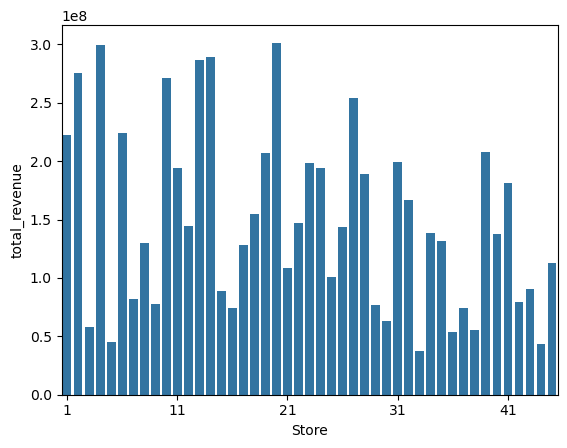

In [6]:
sns.barplot(data = pd.read_sql("""
                SELECT "Store", ROUND(SUM("Weekly_Sales")::numeric, 2) AS Total_Revenue FROM merged_train_data 
                GROUP BY "Store";
            """
           , conn),
            x = "Store", y = "total_revenue")
plt.xticks(range(0, 50, 10))
plt.show()

2. Department number *92* has the highest total revenue earned with a total of 483.94M followed by department number *95* with 449.32M then department number *38* with 393.12M. These should be prioritized for the inventory.

In [7]:
pd.read_sql("""
                SELECT "Dept", ROUND(SUM("Weekly_Sales")::NUMERIC, 2) AS Total_Revenue FROM merged_train_data
                GROUP BY "Dept"
                ORDER BY Total_Revenue DESC
                LIMIT 10;
            """
           , conn)

,Dept,total_revenue
0,92,"483,943,341.87"
1,95,"449,320,162.52"
2,38,"393,118,136.92"
3,72,"305,725,152.21"
4,90,"291,068,463.68"
5,40,"288,936,022.05"
6,2,"280,611,174.43"
7,91,"216,781,705.73"
8,13,"197,321,569.95"
9,8,"194,280,780.73"


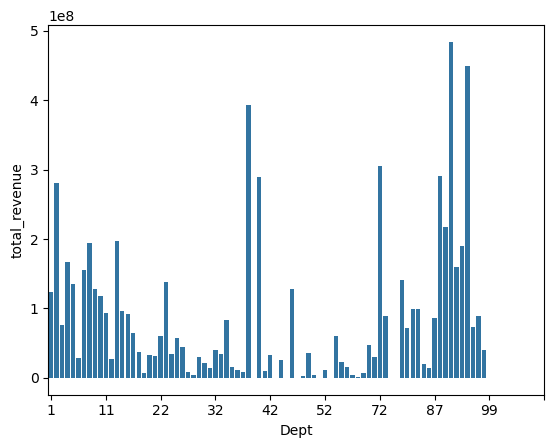

In [8]:
sns.barplot(data = pd.read_sql("""
                SELECT "Dept", ROUND(SUM("Weekly_Sales")::NUMERIC, 2) AS Total_Revenue FROM merged_train_data
                GROUP BY "Dept";
            """
           , conn),
            x = "Dept", y = "total_revenue")
plt.xticks(range(0, 100, 10))
plt.show()

3. Type A stores average 20,099.57 in weekly sales—outperforming Type B by 64.2% and Type C by 111.1%.

In [9]:
pd.read_sql("""
                SELECT "Type", ROUND(AVG("Weekly_Sales")::NUMERIC, 2) AS Average_Revenue FROM merged_train_data
                GROUP BY "Type"
                ORDER BY Average_Revenue DESC;
            """
           , conn)

,Type,average_revenue
0,A,"20,099.57"
1,B,"12,237.08"
2,C,"9,519.53"


In [10]:
t = pd.read_sql("""
                SELECT "Type", ROUND(SUM("Weekly_Sales")::NUMERIC, 2) AS Average_Revenue FROM merged_train_data
                GROUP BY "Type"
                ORDER BY Average_Revenue DESC;
            """
           , conn)
t

,Type,average_revenue
0,A,"4,331,014,722.75"
1,B,"2,000,700,736.82"
2,C,"405,503,527.54"


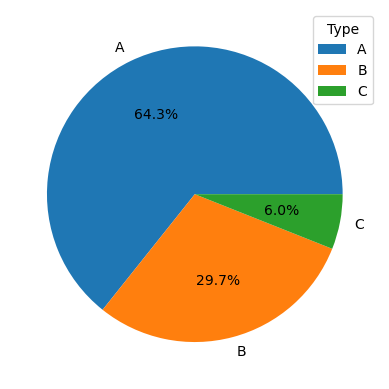

In [11]:
plt.pie(x = t.average_revenue, labels=t.Type, autopct='%1.1f%%')
plt.legend(labels = t.Type, title = "Type")
plt.show()

In [12]:
pd.read_sql("""
                SELECT "Type",
                "Store",
                ROUND(SUM("Weekly_Sales")::numeric, 2) AS "Total_Revenue",
                RANK() OVER(PARTITION BY "Type" ORDER BY ROUND(SUM("Weekly_Sales")::numeric, 2) DESC) AS "Rank"
                FROM merged_train_data
                GROUP BY "Type", "Store";
            """
           , conn)

,Type,Store,Total_Revenue,Rank
0,A,20,"301,397,792.46",1
1,A,4,"299,543,953.38",2
2,A,14,"288,999,911.34",3
3,A,13,"286,517,703.80",4
4,A,2,"275,382,440.98",5
5,A,27,"253,855,916.88",6
6,A,6,"223,756,130.64",7
7,A,1,"222,402,808.85",8
8,A,39,"207,445,542.47",9
9,A,19,"206,634,862.10",10


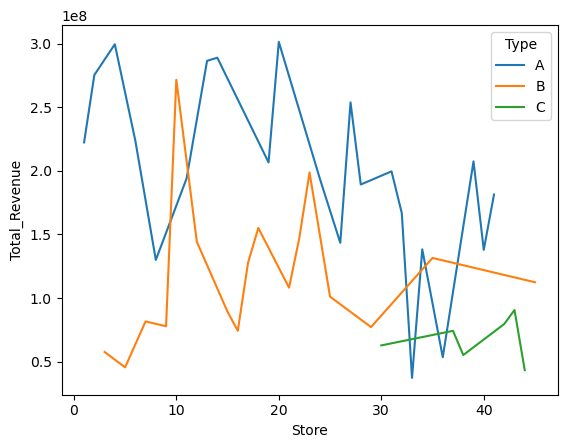

In [13]:
sns.lineplot(data = pd.read_sql("""
                SELECT "Type",
                "Store",
                ROUND(SUM("Weekly_Sales")::numeric, 2) AS "Total_Revenue",
                RANK() OVER(PARTITION BY "Type" ORDER BY ROUND(SUM("Weekly_Sales")::numeric, 2) DESC) AS "Rank"
                FROM merged_train_data
                GROUP BY "Type", "Store";
            """
           , conn),
            x = "Store", y = "Total_Revenue", hue = "Type")
plt.show()

4. While Holiday weeks generate a peak average of 17,035.82, the lift over non-holiday periods (15,901.45) is only 7.14%.

In [14]:
pd.read_sql("""
                SELECT 
                        CASE WHEN "IsHoliday" = TRUE THEN 'Holiday'
                            ELSE 'Not_Holiday'
                        END AS Holiday,
                ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales" FROM merged_train_data
                GROUP BY Holiday
            """
           , conn)

,holiday,Average_Sales
0,Holiday,"17,035.82"
1,Not_Holiday,"15,901.45"


5. Revenue peaks drastically during the 4th quarter holiday season. December (19,355.85) and November (17,491.13) are the top-performing months, while January sees the typical post-holiday cooling period.

In [15]:
pd.read_sql("""
                SELECT EXTRACT(MONTH FROM "Date"::date) AS Month, ROUND(AVG("Weekly_Sales")) AS Average_Revenue
                FROM merged_train_data
                GROUP BY Month
                ORDER BY Average_Revenue DESC;
            """
           , conn)

,month,average_revenue
0,12.00,"19,356.00"
1,11.00,"17,491.00"
2,6.00,"16,326.00"
3,8.00,"16,063.00"
4,2.00,"16,009.00"
5,7.00,"15,861.00"
6,5.00,"15,776.00"
7,4.00,"15,650.00"
8,3.00,"15,417.00"
9,10.00,"15,244.00"


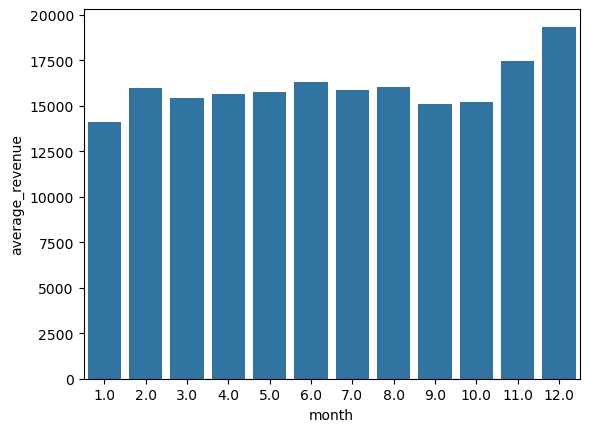

In [16]:
sns.barplot(data = pd.read_sql("""
                SELECT EXTRACT(MONTH FROM "Date"::date) AS Month, ROUND(AVG("Weekly_Sales")) AS Average_Revenue
                FROM merged_train_data
                GROUP BY Month;
            """
           , conn),
            x = "month", y = "average_revenue")
plt.show()

6. By tracking sales across the timeline, we observe a significant 14.74% surge in average sales from October to November. This highlights the precise moment the holiday shopping cycle begins to impact the bottom line.

In [17]:
pd.read_sql("""
                SELECT T."MONTH",
                T."average_revenue",
                LAG(T."average_revenue") OVER(ORDER BY T."MONTH") AS "Previous",
                T."average_revenue" / LAG(T."average_revenue") OVER(ORDER BY T."MONTH") * 100 - 100 AS "Percentage_Increase"
                FROM (
                SELECT EXTRACT(MONTH FROM "Date"::date) "MONTH", ROUND(AVG("Weekly_Sales")) AS "average_revenue"
                FROM merged_train_data
                GROUP BY "MONTH"
                ) AS T;
            """
           , conn)

,MONTH,average_revenue,Previous,Percentage_Increase
0,1.00,"14,126.00",NaN,NaN
1,2.00,"16,009.00","14,126.00",13.33
2,3.00,"15,417.00","16,009.00",-3.70
3,4.00,"15,650.00","15,417.00",1.51
4,5.00,"15,776.00","15,650.00",0.81
5,6.00,"16,326.00","15,776.00",3.49
6,7.00,"15,861.00","16,326.00",-2.85
7,8.00,"16,063.00","15,861.00",1.27
8,9.00,"15,096.00","16,063.00",-6.02
9,10.00,"15,244.00","15,096.00",0.98


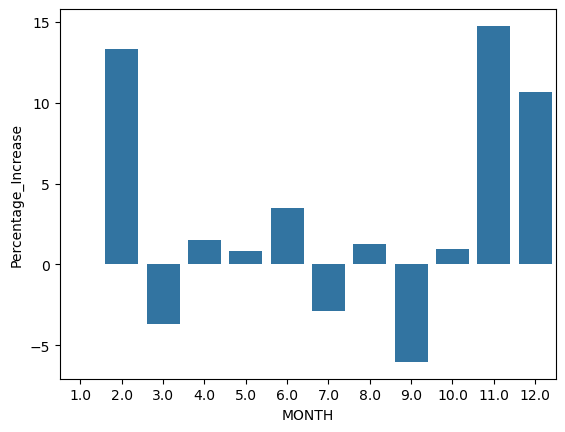

In [18]:
sns.barplot(data = pd.read_sql("""
                SELECT T."MONTH",
                T."average_revenue",
                LAG(T."average_revenue") OVER(ORDER BY T."MONTH") AS "Previous",
                T."average_revenue" / LAG(T."average_revenue") OVER(ORDER BY T."MONTH") * 100 - 100 AS "Percentage_Increase"
                FROM (
                SELECT EXTRACT(MONTH FROM "Date"::date) "MONTH", ROUND(AVG("Weekly_Sales")) AS "average_revenue"
                FROM merged_train_data
                GROUP BY "MONTH"
                ) AS T;
            """
           , conn),
            x = "MONTH", y = "Percentage_Increase")
plt.show()

7. By implementing a 4-week rolling average via SQL Window Functions, I effectively filtered out short-term operational noise. This visualization confirms a steady, sustainable growth trajectory throughout the year.

In [19]:
rolling = pd.read_sql("""
                SELECT 
    "Store",
    "Date",
    "Weekly_Sales",
    ROUND(AVG("Weekly_Sales") OVER (
        PARTITION BY "Store"
        ORDER BY "Date"
        ROWS BETWEEN 3 PRECEDING AND CURRENT ROW
    )::numeric, 2) AS Rolling_4Week_Avg
FROM merged_train_data
WHERE "Store" = 1
ORDER BY "Date";
            """
           , conn)
rolling

,Store,Date,Weekly_Sales,rolling_4week_avg
0,1,2010-02-05,"1,085.29","1,085.29"
1,1,2010-02-05,"40,129.01","20,607.15"
2,1,2010-02-05,"10,217.55","17,143.95"
3,1,2010-02-05,"21,084.08","18,128.98"
4,1,2010-02-05,"2,567.36","18,499.50"
...,...,...,...,...
10239,1,2012-10-26,"12,702.86","13,153.43"
10240,1,2012-10-26,"32,830.52","14,084.17"
10241,1,2012-10-26,"17,918.31","16,504.53"
10242,1,2012-10-26,"26,285.27","22,434.24"


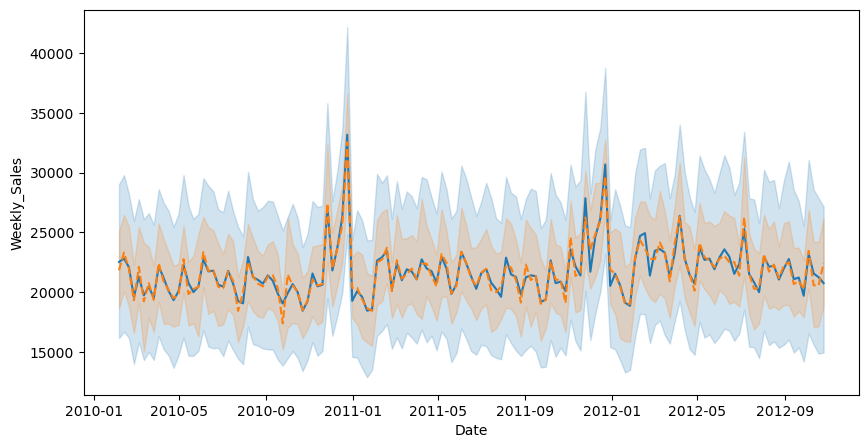

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(rolling, x = "Date", y = "Weekly_Sales", linestyle = '-', ax = ax)
sns.lineplot(rolling, x = "Date", y = "rolling_4week_avg", linestyle = '--', ax = ax)
plt.show()

8. The absolute peak of operational performance was recorded by Store 10, Department number 72, which achieved a staggering 693,099.36 in a single week, setting the record for the highest departmental volume in the dataset. The other 9 in the highest 10 are mostly from department number 72 too, most of them being due to Thanksgivings (NOV 25, 26), and Christmas (DEC 24).

In [21]:
pd.read_sql("""
                SELECT "Store", "Dept", "Date", ROUND(MAX("Weekly_Sales")::numeric, 2) AS "Max_Revenue"
                FROM merged_train_data
                GROUP BY "Store", "Dept", "Date"
                ORDER BY "Max_Revenue" desc
                LIMIT 10;
            """
           , conn)

,Store,Dept,Date,Max_Revenue
0,10,72,2010-11-26,"693,099.36"
1,35,72,2011-11-25,"649,770.18"
2,10,72,2011-11-25,"630,999.19"
3,35,72,2010-11-26,"627,962.93"
4,14,72,2010-11-26,"474,330.10"
5,20,72,2010-11-26,"422,306.25"
6,27,72,2010-11-26,"420,586.57"
7,10,7,2010-12-24,"406,988.63"
8,10,72,2010-12-24,"404,245.03"
9,22,72,2010-11-26,"393,705.20"


9. Analysis identifies Markdown 2 (17,052) and Markdown 4 (17,026) as the most effective promotional tools. While Markdowns 1, 4, and 5 run year-round, Markdowns 2 and 3 are highly seasonal, peaking during specific holiday windows.

In [22]:
pd.read_sql("""
                SELECT CASE WHEN "MarkDown1" = 0 THEN 'Non-Markdown'
                            ELSE 'Markdown'
                       END AS "Markdown1",
                       ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales"
                FROM merged_train_data
                GROUP BY "Markdown1";
            """
           , conn)

,Markdown1,Average_Sales
0,Markdown,"16,215.49"
1,Non-Markdown,"15,850.97"


In [23]:
pd.read_sql("""
                SELECT CASE WHEN "MarkDown2" = 0 THEN 'Non-Markdown'
                            ELSE 'Markdown'
                       END AS "Markdown2",
                       ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales"
                FROM merged_train_data
                GROUP BY "Markdown2";
            """
           , conn)

,Markdown2,Average_Sales
0,Markdown,"17,052.52"
1,Non-Markdown,"15,598.19"


In [24]:
pd.read_sql("""
                SELECT CASE WHEN "MarkDown3" = 0 THEN 'Non-Markdown'
                            ELSE 'Markdown'
                       END AS "Markdown3",
                       ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales"
                FROM merged_train_data
                GROUP BY "Markdown3";
            """
           , conn)

,Markdown3,Average_Sales
0,Markdown,"16,738.21"
1,Non-Markdown,"15,616.75"


In [25]:
pd.read_sql("""
                SELECT CASE WHEN "MarkDown4" = 0 THEN 'Non-Markdown'
                            ELSE 'Markdown'
                       END AS "Markdown4",
                       ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales"
                FROM merged_train_data
                GROUP BY "Markdown4";
            """
           , conn)

,Markdown4,Average_Sales
0,Markdown,"17,026.38"
1,Non-Markdown,"15,489.09"


In [26]:
pd.read_sql("""
                SELECT CASE WHEN "MarkDown5" = 0 THEN 'Non-Markdown'
                            ELSE 'Markdown'
                       END AS "Markdown5",
                       ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Sales"
                FROM merged_train_data
                GROUP BY "Markdown5";
            """
           , conn)

,Markdown5,Average_Sales
0,Markdown,"16,177.02"
1,Non-Markdown,"15,871.52"


10. There is a severe negative correlation between local labor markets and revenue. As unemployment rises from 3.9% (29,929.38 avg) to 14.2% (13,670.36 avg), sales volume experiences a massive 51% contraction.

In [27]:
pd.read_sql("""
                SELECT 
    ROUND(f."Unemployment"::numeric, 1) AS Unemployment_Rate,
    ROUND(AVG(t."Weekly_Sales")::numeric, 2) AS Average_Sales
FROM train_data t
JOIN cleaned_features f ON t."Store" = f."Store" AND t."Date"::date = f."Date"::date
GROUP BY Unemployment_Rate
ORDER BY Unemployment_Rate;
            """
           , conn)

,unemployment_rate,average_sales
0,3.90,"29,929.35"
1,4.10,"20,562.18"
2,4.20,"17,363.46"
3,4.30,"20,327.14"
4,4.40,"18,981.00"
...,...,...
69,13.70,"14,002.44"
70,14.00,"14,528.94"
71,14.10,"14,115.82"
72,14.20,"13,670.05"


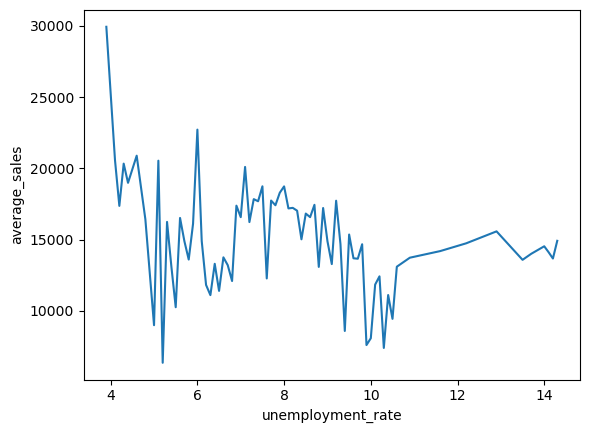

In [28]:
sns.lineplot(data = pd.read_sql("""
                SELECT 
    ROUND(f."Unemployment"::numeric, 1) AS Unemployment_Rate,
    ROUND(AVG(t."Weekly_Sales")::numeric, 2) AS Average_Sales
FROM train_data t
JOIN cleaned_features f ON t."Store" = f."Store" AND t."Date"::date = f."Date"::date
GROUP BY Unemployment_Rate
ORDER BY Unemployment_Rate;
            """
           , conn),
            x = "unemployment_rate", y = "average_sales")
plt.show()

11. There is a direct linear relationship between physical square footage and revenue. Larger stores consistently achieve higher weekly sales, proving that the scale of a store's Size is one of the strongest predictors of its earning potential.

In [29]:
pd.read_sql("""
                SELECT "Size", ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Revenue"
                FROM merged_train_data
                GROUP BY "Size"
                ORDER BY "Average_Revenue" DESC
                LIMIT 10;
            """
           , conn)

,Size,Average_Revenue
0,203742,"29,508.30"
1,205863,"29,161.21"
2,200898,"28,784.85"
3,219622,"27,355.14"
4,202307,"26,898.07"
5,126512,"26,332.30"
6,204184,"24,826.98"
7,202505,"21,913.24"
8,151315,"21,710.54"
9,184109,"21,000.76"


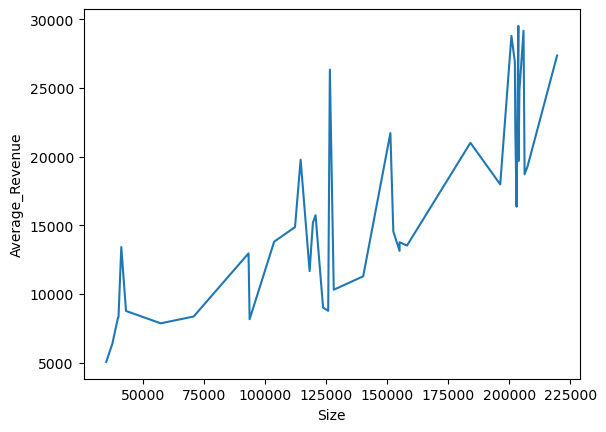

In [30]:
sns.lineplot(data= pd.read_sql("""
                SELECT "Size", ROUND(AVG("Weekly_Sales")::numeric, 2) AS "Average_Revenue"
                FROM merged_train_data
                GROUP BY "Size";
            """
           , conn),
            x = "Size", y = "Average_Revenue")
plt.show()

12. Temperatue peaks at around the month of July and is lowest at the start and end of the years.

In [31]:
pd.read_sql("""
                SELECT EXTRACT(MONTH FROM "Date"::date) AS "Month", ROUND(AVG("Temperature")::numeric, 2) AS "Average_Temperature"
                FROM merged_train_data
                GROUP BY "Month"
                ORDER BY "Average_Temperature" DESC;
            """
           , conn)

,Month,Average_Temperature
0,7.00,79.36
1,8.00,78.82
2,6.00,74.74
3,9.00,71.89
4,5.00,64.96
5,10.00,61.01
6,4.00,57.08
7,11.00,49.39
8,3.00,49.28
9,12.00,39.65


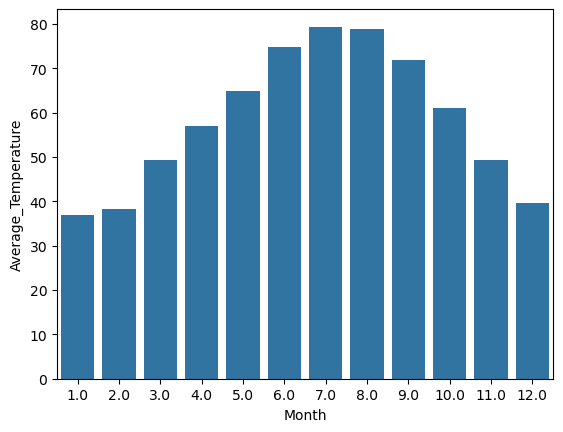

In [32]:
sns.barplot(data = pd.read_sql("""
                SELECT EXTRACT(MONTH FROM "Date"::date) AS "Month", ROUND(AVG("Temperature")::numeric, 2) AS "Average_Temperature"
                FROM merged_train_data
                GROUP BY "Month"
                ORDER BY "Average_Temperature" DESC;
            """
           , conn),
           x = "Month", y = "Average_Temperature")
plt.show()

13. The highest increase in fuel price happened between 2010 september to 2011 may which is about 36% increase.

In [33]:
pd.read_sql("""
                SELECT "Date", ROUND(AVG("Fuel_Price")::numeric, 2) AS "Average_Fuel_Price"
                FROM merged_train_data
                GROUP BY "Date"
                ORDER BY "Date" desc;
            """
           , conn)

,Date,Average_Fuel_Price
0,2012-10-26,3.79
1,2012-10-19,3.88
2,2012-10-12,3.90
3,2012-10-05,3.85
4,2012-09-28,3.86
...,...,...
138,2010-03-05,2.73
139,2010-02-26,2.69
140,2010-02-19,2.67
141,2010-02-12,2.70


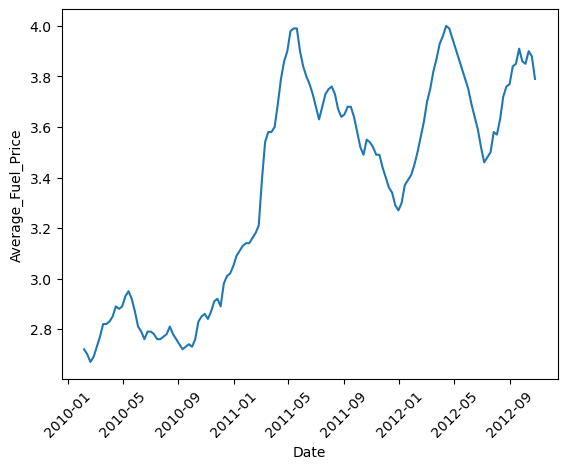

In [34]:
sns.lineplot(data = pd.read_sql("""
                SELECT "Date", ROUND(AVG("Fuel_Price")::numeric, 2) AS "Average_Fuel_Price"
                FROM merged_train_data
                GROUP BY "Date";
            """
           , conn),
            x = "Date", y = "Average_Fuel_Price")
plt.xticks(rotation = 45)
plt.show()

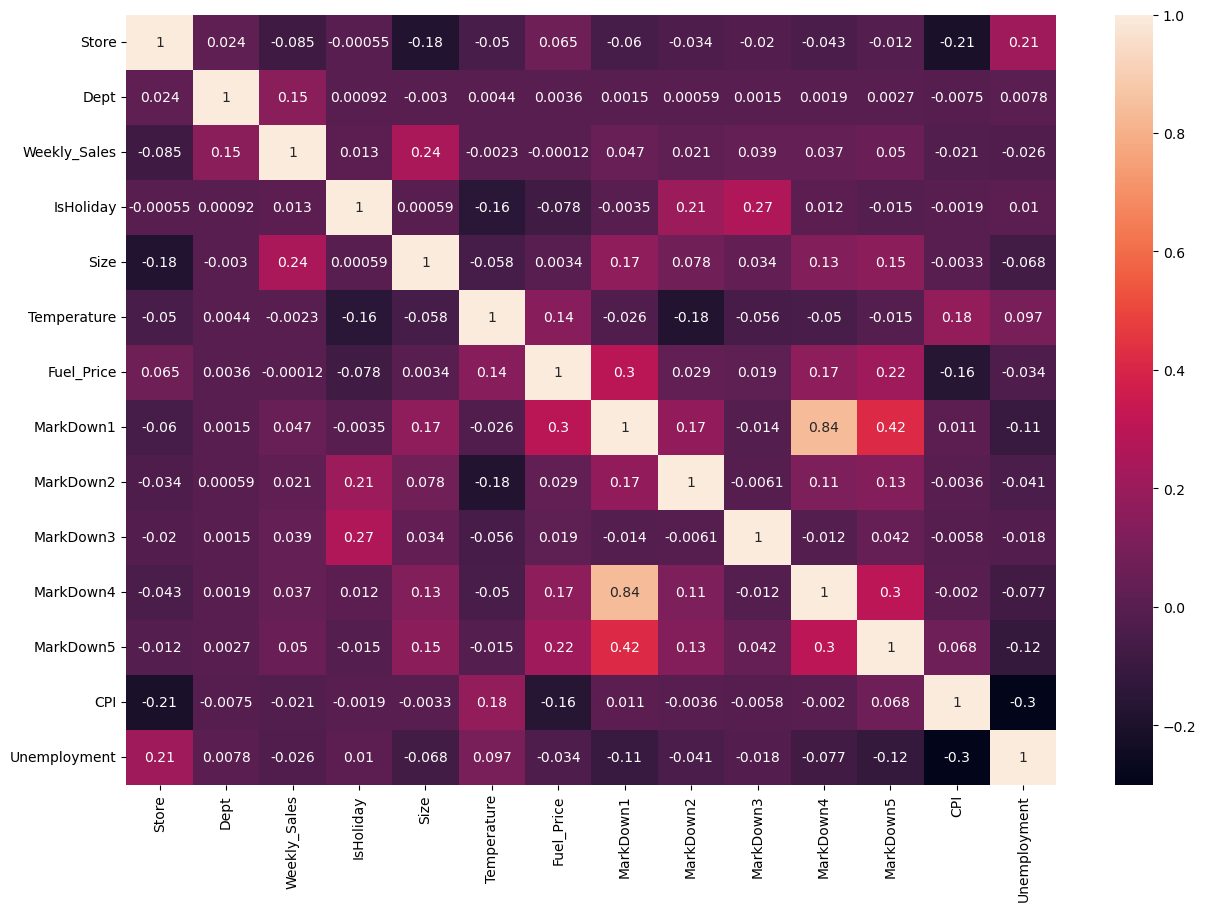

In [36]:
fig, ax = plt.subplots(figsize = (15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, ax = ax)
plt.show(fig)